В домашнем задании нужно решить задачу классификации точек наиболее эффективно. Для этого в работе необходимо применить различные методы по отбору признаков. Отбор признаков предпочтительнее осуществлять, основываясь на математическом аппарате, поэтому данные для этого задания будут сгенерированы, чтобы избежать признаков с физическим смыслом.

Этапы работы:
- Сгенерируйте данные с помощью кода:
from sklearn.datasets import make_classification
x_data_generated, y_data_generated = make_classification(scale=1)
- Постройте модель логистической регрессии и оцените среднюю точность. Для этого используйте следующий код:
cross_val_score(LogisticRegression(), x, y, scoring=‘accuracy’).mean()
- Используйте статистические методы для отбора признаков:
a) Выберите признаки на основе матрицы корреляции.
b) Отсеките низковариативные признаки (VarianceThreshold).
c) Повторите п. 2 на отобранных признаках в п. 3a, п. 3b.
- Осуществите отбор признаков на основе дисперсионного анализа:
a) Выберите 5 лучших признаков с помощью скоринговой функции для классификации f_classif (SelectKBest(f_classif, k=5)).
b) Повторите п. 2 на отобранных признаках.
- Отбор с использованием моделей:
a) Реализуйте отбор признаков с помощью логистической регрессии. Отобранные признаки подайте далее на вход в саму логистическую регрессию (SelectFromModel). Используйте L1 регуляризацию.
b) Реализуйте отбор признаков с помощью модели RandomForest и встроенного атрибута feature_impotance.
c) Повторите п. 2 на отобранных признаках в п. 5a, п. 5b.
- Перебор признаков:
a) SequentialFeatureSelector.
b) Повторите п. 2 на отобранных признаках.
- Сформулируйте выводы по проделанной работе:
a) Сделайте таблицу вида |способ выбора признаков|количество признаков|средняя точность модели|.



In [ ]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
x_gen, y_gen = make_classification(scale=1, random_state=9)
x_gen.shape, y_gen.shape

((100, 20), (100,))

In [ ]:
x_map = pd.DataFrame(x_gen)
x_map.corr().style.background_gradient(cmap='cividis')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.000000,-0.031400,-0.124719,0.227952,-0.039669,0.008475,0.002980,0.020154,0.059414,0.135268,-0.153262,0.063610,0.179177,0.065036,0.010816,-0.053966,-0.125639,-0.062948,-0.033934,-0.021112
1,-0.031400,1.000000,-0.049903,0.098799,-0.004746,-0.215948,0.049646,0.049775,0.250644,-0.032055,-0.035216,-0.175420,0.058578,-0.143990,0.043808,0.048970,0.102816,0.174688,0.044627,0.095289
2,-0.124719,-0.049903,1.000000,0.068601,-0.077628,-0.040216,-0.133043,-0.020705,-0.083956,-0.022989,0.207202,-0.040398,0.065487,-0.054203,0.091816,-0.102191,-0.078314,0.039579,0.039408,-0.067163
3,0.227952,0.098799,0.068601,1.000000,0.123978,-0.196373,0.103752,0.093928,0.060212,0.096490,0.136188,0.068491,0.054319,0.217036,-0.006861,0.054729,0.025833,-0.063234,-0.240047,-0.062766
4,-0.039669,-0.004746,-0.077628,0.123978,1.000000,0.060588,0.111912,-0.080980,0.104629,-0.259849,-0.049722,0.012883,-0.116725,0.026897,0.039045,-0.045360,0.115545,-0.012324,-0.025872,0.029303
5,0.008475,-0.215948,-0.040216,-0.196373,0.060588,1.000000,-0.114471,0.037046,-0.035419,-0.209459,-0.069581,0.173938,-0.041171,0.062412,0.090621,0.098301,-0.028771,-0.175696,0.066996,0.148329
6,0.002980,0.049646,-0.133043,0.103752,0.111912,-0.114471,1.000000,-0.108842,0.077029,-0.062414,0.002106,0.091717,0.039247,0.073273,0.081370,-0.066061,-0.019353,-0.091397,-0.020550,0.035800
7,0.020154,0.049775,-0.020705,0.093928,-0.080980,0.037046,-0.108842,1.000000,-0.073145,-0.092143,0.000526,-0.087704,0.013267,-0.004582,-0.113739,-0.132013,0.184916,0.089422,-0.071003,-0.011177
8,0.059414,0.250644,-0.083956,0.060212,0.104629,-0.035419,0.077029,-0.073145,1.000000,-0.085400,-0.216015,-0.041755,0.181018,0.008869,0.062250,0.058623,0.097774,0.042915,-0.049101,0.008735
9,0.135268,-0.032055,-0.022989,0.096490,-0.259849,-0.209459,-0.062414,-0.092143,-0.085400,1.000000,0.124372,-0.097175,0.091153,0.003595,-0.082467,-0.005388,0.055199,0.099347,-0.090675,-0.039976


In [ ]:
# Логистическая регрессия
logreg = LogisticRegression(random_state=7).fit(x_gen, y_gen)
logreg_mean = cross_val_score(logreg, x_gen, y_gen, cv=5, scoring='accuracy').mean()
logreg_mean

0.86

In [ ]:
# Статистические методы для отбора признаков:
# На основе матрицы корреляции и по порогу VarianceThreshold

In [ ]:
x = pd.DataFrame(x_gen)
y = pd.Series(y_gen)
x['Target'] = y
x.head(3)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,Target
0,-0.061000,-0.868975,0.043621,-2.757511,-1.304449,0.074567,-1.990860,-1.336837,-0.486052,0.954555,...,0.769176,1.529572,0.338366,-2.621578,1.159243,0.956275,-0.437646,0.347415,0.476281,1
1,-1.058712,-1.282205,0.167144,0.144471,-0.861473,0.158882,1.756368,-1.897736,-0.651007,0.337486,...,0.915471,-1.796172,1.798489,-0.541945,0.236401,-0.176654,-0.503043,-1.063231,-0.854900,1
2,1.101442,-1.398838,-0.583313,0.137913,1.249654,1.336861,-0.715492,0.029136,-0.058943,0.337582,...,1.100319,-0.936254,1.818105,1.387800,0.430021,0.341622,-0.609006,-0.914463,1.141516,1


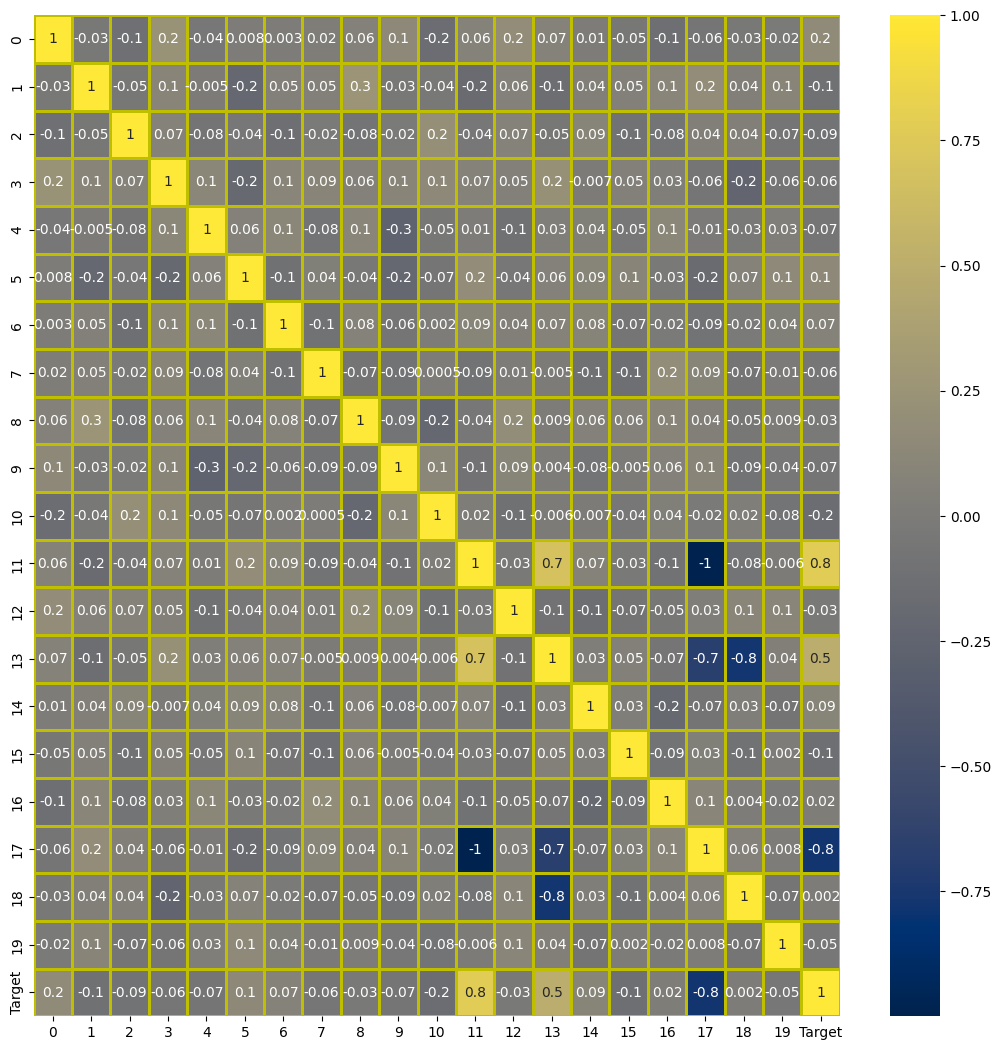

In [ ]:
plt.figure(figsize=(13,13))
sns.heatmap(x.corr(), annot=True, fmt='.1g', linecolor='y', linewidth=2, cmap='cividis')
plt.show()

In [ ]:
# Убрать признаки на основе матрицы корреляции - 4 признака (8, 12, 16, 18)
x['Target'] = y

In [ ]:
x = x.loc[:, [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 13, 14, 15, 17, 19]]
x.head(3)

,0,1,2,3,4,5,6,7,9,10,11,13,14,15,17,19
0,-0.061000,-0.868975,0.043621,-2.757511,-1.304449,0.074567,-1.990860,-1.336837,0.954555,-0.839500,0.769176,0.338366,-2.621578,1.159243,-0.437646,0.476281
1,-1.058712,-1.282205,0.167144,0.144471,-0.861473,0.158882,1.756368,-1.897736,0.337486,-0.196260,0.915471,1.798489,-0.541945,0.236401,-0.503043,-0.854900
2,1.101442,-1.398838,-0.583313,0.137913,1.249654,1.336861,-0.715492,0.029136,0.337582,-1.526132,1.100319,1.818105,1.387800,0.430021,-0.609006,1.141516


In [ ]:
logreg1 = LogisticRegression(random_state=7).fit(x, y)
corr_mat_mean = cross_val_score(logreg1, x, y, cv=5, scoring='accuracy').mean()
corr_mat_mean

0.8799999999999999

In [ ]:
VarianceThreshold(.7).fit_transform(x_gen).shape

(100, 19)

In [ ]:
VarianceThreshold(.8).fit_transform(x_gen).shape

(100, 17)

In [ ]:
low_var = VarianceThreshold(.9).fit_transform(x_gen)
low_var.shape

(100, 16)

In [ ]:
low_var[0]

array([-0.06100001, -0.86897544,  0.0436206 , -2.7575107 , -1.30444877,
        0.07456735, -1.9908596 , -1.33683673, -0.83950036,  0.76917564,
        1.52957204,  0.33836619,  1.15924262,  0.95627522,  0.347415  ,
        0.47628115])

In [ ]:
logreg2 = LogisticRegression(random_state=7).fit(low_var, y_gen)
var_thr_mean = cross_val_score(logreg2, low_var, y_gen, cv=5, scoring='accuracy').mean()
var_thr_mean
# без 4 признаков с низкой дисперсией в соответствии с установленным порогом

0.8699999999999999

In [ ]:
# На основе дисперсионного анализа:
# Выбрать 5 лучших признаков с помощью скоринговой функции для классификации f_classif (SelectKBest(f_classif, k=5))

In [ ]:
x_best = SelectKBest(f_classif, k=5)
x_best.fit(x_gen, y_gen)

# оценки для признаков
x_best.scores_

array([2.62348914e+00, 1.27644388e+00, 7.75922211e-01, 3.41715938e-01,
       4.31544086e-01, 1.84963260e+00, 5.52422424e-01, 3.81962327e-01,
       9.40817469e-02, 4.20500281e-01, 2.69021236e+00, 1.49019302e+02,
       7.41263630e-02, 3.15178267e+01, 8.65064028e-01, 1.55888656e+00,
       2.58134264e-02, 1.50203080e+02, 4.23255823e-04, 2.02670032e-01])

In [ ]:
x_best = x_best.transform(x_gen)

In [ ]:
x_best.shape

(100, 5)

In [ ]:
x_best[0]

array([-0.06100001, -0.83950036,  0.76917564,  0.33836619, -0.43764595])

In [ ]:
logreg3 = LogisticRegression(random_state=7).fit(x_best, y_gen)
k_best_mean = cross_val_score(logreg3, x_best, y_gen, cv=5, scoring='accuracy').mean()
k_best_mean

0.89

In [ ]:
# Отбор с использованием моделей:
# Логистическая регрессия + SelectFromModel с L1.
# RandomForest и feature impotance.

In [ ]:
logr = LogisticRegression(penalty='l1', solver='liblinear', random_state=7).fit(x_gen, y_gen)
logr = SelectFromModel(logr, prefit=True)
x_new = logr.transform(x_gen)
x_new.shape

(100, 11)

In [ ]:
logreg4 = LogisticRegression(random_state=7).fit(x_new, y_gen)
sel_mod_mean = cross_val_score(logreg4, x_new, y_gen, cv=5, scoring='accuracy').mean()
sel_mod_mean

0.8700000000000001

In [ ]:
ran_for = RandomForestClassifier(random_state=7).fit(x_gen, y_gen)
feature = pd.Series(ran_for.feature_importances_)
feature.sort_values(ascending=False, inplace=True)

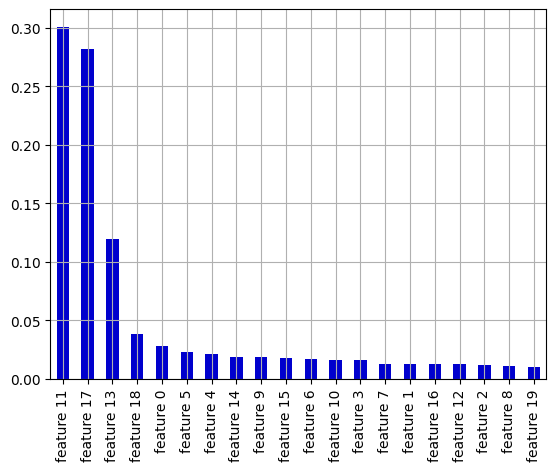

In [ ]:
feature_names = [f"feature {i}" for i in range(x_gen.shape[1])]
forest_importances = pd.Series(ran_for.feature_importances_, index=feature_names)
forest_importances.sort_values(ascending=False, inplace=True)
forest_importances.plot.bar(color='mediumblue')
plt.grid()
plt.show()

In [ ]:
feature = pd.DataFrame(x_gen)
best_feat = feature.loc[:, [0, 11, 13, 17, 18]]
best_feat.head(3)

,0,11,13,17,18
0,-0.061000,0.769176,0.338366,-0.437646,0.347415
1,-1.058712,0.915471,1.798489,-0.503043,-1.063231
2,1.101442,1.100319,1.818105,-0.609006,-0.914463


In [ ]:
logreg5 = LogisticRegression(random_state=7).fit(best_feat, y_gen)
ran_for_mean = cross_val_score(logreg5, best_feat, y_gen, cv=5, scoring='accuracy').mean()
ran_for_mean

0.9099999999999999

In [ ]:
# Перебор признаков: SequentialFeatureSelector.
knn = KNeighborsClassifier()
sfs = SequentialFeatureSelector(knn, n_features_to_select=10).fit(x_gen, y_gen)
sfs = sfs.transform(x_gen)
sfs.shape

(100, 10)

In [ ]:
sfs[0]

array([-0.06100001, -2.7575107 , -1.30444877,  0.07456735, -1.9908596 ,
        0.76917564, -2.62157808,  1.15924262,  0.95627522, -0.43764595])

In [ ]:
logreg6 = LogisticRegression(random_state=7).fit(sfs, y_gen)
sfs_mean = cross_val_score(logreg6, sfs, y_gen, cv=5, scoring='accuracy').mean()
sfs_mean

0.89

In [ ]:
sfs_lg = SequentialFeatureSelector(LogisticRegression(random_state=7), n_features_to_select=10).fit(x_gen, y_gen)
sfs_lg = sfs_lg.transform(x_gen)
sfs_lg.shape

(100, 10)

In [ ]:
logreg7 = LogisticRegression(random_state=7).fit(sfs_lg, y_gen)
sfs_lg_m = cross_val_score(logreg7, sfs_lg, y_gen, cv=5, scoring='accuracy').mean()
sfs_lg_m

0.93

In [ ]:
result = pd.DataFrame({'Способ отбора признаков': ['Logistic Regression', 'Correlation matrix',
                        'Variance Threshold', 'SelectKBest (Logreg)', 'SelectFromModel',
                        'RandomForest', 'SequentialFeatureSelector (KNN)', 'SequentialFeatureSelector (LogReg)'],
                        'Количество признаков': [20, 16, 16, 5, 11, 5, 10, 10],
                        'Средняя точность модели': [logreg_mean, corr_mat_mean,
                        var_thr_mean, k_best_mean, sel_mod_mean, ran_for_mean, sfs_mean, sfs_lg_m]})

result.sort_values(by='Средняя точность модели', ascending=False)

,Способ отбора признаков,Количество признаков,Средняя точность модели
7,SequentialFeatureSelector (LogReg),10,0.93
5,RandomForest,5,0.91
3,SelectKBest (Logreg),5,0.89
6,SequentialFeatureSelector (KNN),10,0.89
1,Correlation matrix,16,0.88
4,SelectFromModel,11,0.87
2,Variance Threshold,16,0.87
0,Logistic Regression,20,0.86
